## Challenge Exercise 4 (CE4)

### See Canvas for assignment dates.

****

## Collaboration policy

This is a group assignment. **The maximum number of students per group is two**. There are no existing group assignments. Additionally, you may choose any classmate (i.e., the overlap criteria have been reset).

Please be **welcoming and considerate** when forming groups. You are encouraged to reach out to classmates you may not know well and to act as a supportive, inclusive member of the class. If you are unsure about what is or is not allowed, **you must ask for clarification in advance**. Claiming confusion or uncertainty after the fact will not be accepted as an excuse.

**Collaboration is permitted only within your team.** There may be **no collaboration, discussion, or sharing of work between different teams**. All submitted work must be **entirely the product of your own team**.

To ensure fairness for everyone, the **collaboration policy will be strictly enforced**. Any violation may result in **a zero for all students involved**.

In the Markdown cell below, list the full names of all members of your group.


### Team members

1. Yahan Yang

****
## AI policy

AI may not be used to generate a coding solution. Your solution must be your own work. If you have any questions about what is or isn't allowed, you must ask. Saying afterwards that you didn't understand or were unsure is not an acceptable excuse.

To ensure fairness for everyone, the **AI policy will be strictly enforced**. Any violation may result in **a zero for all students involved**.


****
## Honor pledge

To acknowledge and understand the **Collaboration and AI policies** outlined above, each team member must enter their Onyen and PID in this markdown cell.

1. ayahan, 730649168

****

## Python modules

All the Python modules needed to complete this CE are provided to you. 

<span style="background-color: #FFFF00">**No other modules are authorized** and **if other modules are added points will be deducted**.</span>


In [108]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score as acc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import math
import warnings
warnings.filterwarnings('ignore')

# Tips

- This numpy <a href="https://numpy.org/doc/stable/user/absolute_beginners.html">tutorial</a> may be helpful.
- This dataframe <a href="https://pandas.pydata.org/docs/user_guide/indexing.html">selecting, slicing, and extracting tutorial</a> may be helpful.
- This datafame <a href="https://www.geeksforgeeks.org/python/filter-pandas-dataframe-with-multiple-conditions/">conditional filtering tutorial</a> maybe be helpful.
- The data visualization notebook (see Canvas schedule) may be helpful.
- The data representation slides (see Canvas schedule) may be helpful.
- The performance evaluation slides (see Canvas schedule) may be helpful.
- The introduction to supervised learning slides (see Canvas schedule) may be helpful.
- The regression slides (see Canvas schedule) may be helpful.
- The classification slides (see Canvas schedule) may be helpful.


****

### Identifying TLE biomarkers in neurological data.

<img src="scgm_structures.png" width="400" style="float: right"/>

The Enigma dataset examines differences between the healthy brain and the brain of a patient with temporal lobe epilepsy (TLE) by analyzing subcortical gray matter structures.

The dataset has the following fields:
- Diagnosis label where 0= healthy and 1=TLE (`Dx`)
- Surface area ($mm^2$) of the left and right thalamus (`L_thal` and `R_thal`).
- Surface area ($mm^2$) of the left and right caudate nucleus (`L_caud` and `R_caud`).
- Surface area ($mm^2$) of the left and right putamen (`L_put and R_put`).
- Surface area ($mm^2$) of the left and right pallidum (`L_pal` and `R_pal`).
- Surface area ($mm^2$) of the left and right hippocampus (`L_hippo` and `R_hipp`).

****

In [109]:
df_enigma = pd.read_csv("enigma.csv")
df_enigma

,Dx,L_thal,R_thal,L_caud,R_caud,L_put,R_put,L_pal,R_pal,L_hippo,R_hippo,L_amyg,R_amyg
0,0,7829.0,7568.0,3301.0,3694.0,4942.0,5403.0,1627.0,1920.0,3927.0,3844.0,1442.0,1409.0
1,0,7567.0,7578.0,3467.0,3494.0,5282.0,5255.0,1769.0,1670.0,4657.0,4582.0,1596.0,1595.0
2,0,7823.0,8228.0,4218.0,4092.0,5473.0,5562.0,1876.0,1450.0,4909.0,4497.0,1550.0,1460.0
3,0,8022.0,8030.0,3892.0,3789.0,5220.0,5510.0,1663.0,1655.0,4551.0,4606.0,1554.0,1594.0
4,0,8443.0,7831.0,4291.0,4400.0,6516.0,6326.0,1915.0,1881.0,4619.0,4338.0,1752.0,1795.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1231,1,6808.2,6034.1,2871.5,3018.9,5251.6,4940.2,1255.0,1182.4,3801.8,3737.1,1697.7,1913.7
1232,1,7466.2,6745.6,3289.1,3524.0,5236.6,5737.7,1467.4,1505.2,3283.6,4356.0,1456.1,1472.2
1233,1,8123.5,6577.2,4253.8,4485.0,5199.6,5815.4,1523.6,1605.8,4486.9,4911.1,1729.8,1994.2
1234,1,9480.4,6428.7,4080.6,4283.0,4822.9,5902.5,1163.5,1362.4,3559.1,4128.0,1522.9,2447.7


****

**P1** (5 Points): Data Visualization.

<img src="p1.png" width="400" style="float: right"/>

First, preprocess your data with `StandardScaler`.

Create a scatter plot that visualizes the relationships between the surface areas of the `Left Hippocampus` and `Right Hippocampus`.

To receive full credit, your new dataframe must generate scatter plots identical to the ones provided.

**Plot Requirements**

- All the data (in your dataframe) is used to generate these scatter plots.
- The colors used to generate plots are blue (healthy) and red (TLE).
- The plot figure size is 5 inches in width and 5 inches in height.
- The plot figure uses a tight layout.
- The default x-axis and y-axis tick values are used.
- The scatter plot marker size is 30.
- The alpha (opacity) value is 0.25.

****

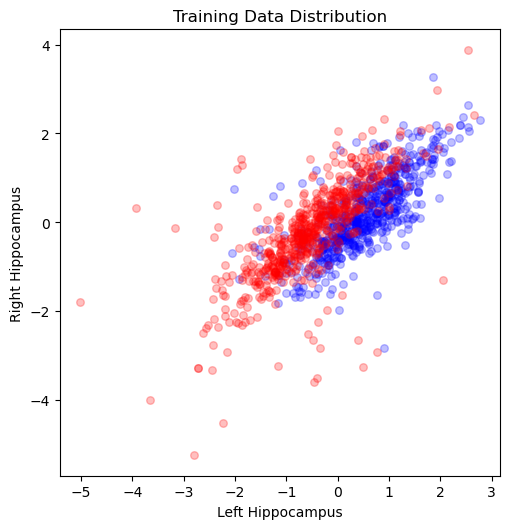

In [110]:
# --------------------------------------
# Add your P1 coding solution below.
# --------------------------------------

scalar = StandardScaler()
labels = df_enigma.drop(columns=['Dx'])
processed_values =  scalar.fit_transform(labels)

processed_df = pd.DataFrame(processed_values, columns= labels.columns)
processed_df['Dx'] = df_enigma['Dx'].values

healthy = processed_df[processed_df['Dx']== 0]
tle = processed_df[processed_df['Dx'] == 1]

plt.figure(figsize=(5, 5))
plt.scatter(healthy['L_hippo'], healthy['R_hippo'], color='blue', s=30, alpha=0.25)
plt.scatter(tle['L_hippo'], tle['R_hippo'], color='red', s=30, alpha=0.25)
plt.tight_layout()
plt.title("Training Data Distribution")
plt.xlabel("Left Hippocampus")
plt.ylabel("Right Hippocampus")
plt.show()










****

<img src="p2.png" width="600" style="float: right"/>



**P2** (10 Points): Gradient descent optimized logistic regression model.

Using the dataframe, this question will construct and evaluate a **logistic regression classification model** that predicts the label (Healthy and TLE) based on the surface area measurements of the right and left hippocampus, optimized with **stochastic gradient descent**.

**Dataset preparation**

Before model construction and evaluation, the data will be randomly shuffled and then partitioned into two sets using an 80/20 split. Specifically, 80% of the data will be used to train, and 20% will be reserved for testing. 

**Model Training and Evaluation**

You are required to implement a **handwritten logistic regression model**, as specified in the slides. **Stochastic gradient descent** will be used to estimate the optimal parameters.

Train five models with varying sizes of each subset (the **batch size**).
  - Use the following batch sizes: `[4,8,16,32,64]`.
  - Initialize all parameters to zeros.
  - Fix the number of training iterations to `1000` iterations with a learning rate of `0.1`.

Next, select the model with the **highest accuracy** on the training set, and report the accuracy (ACC) for both the training and testing datasets for the final model in the plot title. Also, visualize the decision boundary on top of a scatterplot of the testing set.


Additionally, for each batch size, compute and plot the **negative log-likelihood** after `1000` iterations on the **entire training set**.

To receive full credit, your solution must generate a plot similar to the reference plot. <span style="background-color: #FFFF00">**Note**: because the data is randomly shuffled each time the cell is run, your plot and measures will be slightly different than those provided in the reference plot.</span>


**Figure Requirements**

Only the **testing data** is used to generate the scatter plots.
- The colors used to generate plots are blue (Healthy), red (TLE), and green (fitted decision boundary).
- The accuracy (ACC) measure for both the training and test datasets is reported in the plot title. These may be calculated using the <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html">accuracy_score</a> function (see authorized Python modules above). Round the accuracies to two 2 decimal places.
- The default x-axis and y-axis tick values are used.
- The scatter plot marker size is 30.
- The alpha (opacity) value is 0.25.
- <span style="background-color: #FFFF00">You must not use existing logistic regression implementations or gradient-descent minimization functions such as `sklearn.linear_model.LogisticRegression` or `scipy.minimize`.</span>

<ins>Note(s)</ins>:
- As given in the slides, the negative log-likelihood  is
$$
\frac{1}{n} \sum_{i=1}^{n} (y_i \theta^T x_i + \log (\sigma(-\theta^T x_i)))
$$

where $(x_1, \dots ,x_n)$ are your data points in the training set with corresponding labels $(y_1, \dots, y_n)$.


<!-- - You choose the free parameters (e.g., learning rate ($\alpha$), regularization ($\lambda$), iterations ($N$)). -->


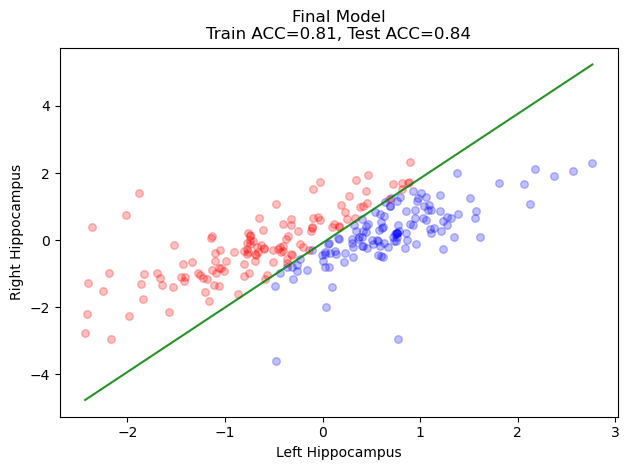

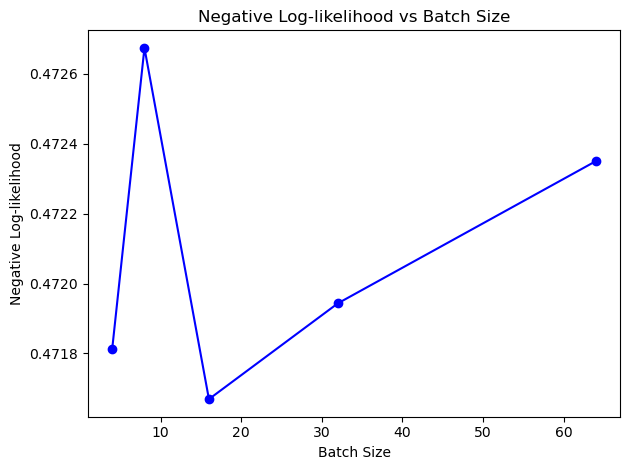

In [111]:
# --------------------------------------
# Add your P2 coding solution below.
# --------------------------------------

# The logistic regression model
def sigmoid(z):
    return 1/(1+(math.e**-z))

def SGD_trainer(X, y, lr, batch, epochs):
    N = epochs 
    params = np.zeros((X.shape[1],1))
    final_nll = {}
    trained_paras = {}
    batch_acc = {}

    for size in batch:
        params = np.zeros((X.shape[1],1))
        shuffled_indices = np.random.permutation(len(X))
        for epoch in range(N):
            batch_indices = np.random.choice(len(X), size=size, replace=False)
            Xs = X[batch_indices]
            ys = y[batch_indices]
            
            y_pred = sigmoid(Xs @ params)
            dw = (-1/Xs.shape[0]) * Xs.T @ (ys-y_pred)
            params = params - lr * dw
            
        theta = X @ params
        nll = -(1/len(X)) * np.sum(y * theta + np.log(sigmoid(-theta)))
        final_nll[size] = nll
        trained_paras[size] = params
            
    return final_nll, trained_paras

batch = [4,8,16,32,64]
lr = 0.1
epoch = 1000

shuffled_df = processed_df.sample(frac=1)
train_df = shuffled_df.sample(frac=.8, random_state = 1)
# print(train_df)
test_df = shuffled_df.drop(train_df.index)
# print(test_df.head())

x_train_raw = train_df[['L_hippo', 'R_hippo']].to_numpy()
ones_train = np.ones(x_train_raw.shape[0])
x_train = np.column_stack((ones_train, x_train_raw))
y_train = train_df['Dx'].to_numpy().reshape(-1,1)

x_test_raw = test_df[['L_hippo', 'R_hippo']].to_numpy()
ones_test = np.ones(x_test_raw.shape[0])
x_test = np.column_stack((ones_test, x_test_raw)) 
y_test = test_df['Dx'].to_numpy().reshape(-1,1)

final_nll, trained_paras = SGD_trainer(x_train, y_train, lr, batch, epoch) 

max_acc, best_param, best_batch = -1, None, None

# compute acc for each trained_paras and output to determine best
for size, param in trained_paras.items():
    train_y_pred = (sigmoid(x_train @ param) >= 0.5).astype(int).flatten()
    # print(train_y_pred)
    accuracy = acc(y_train,train_y_pred)
    if accuracy > max_acc:
        max_acc = accuracy 
        best_param = param
        best_batch = size


test_y_pred = (sigmoid(x_test @ best_param) >= 0.5).astype(int)
test_y_pred = test_y_pred.flatten()  
test_acc = acc(y_test, test_y_pred) 
# print(test_y_pred)
healthy = test_y_pred == 0
tle = test_y_pred == 1

# print("test_y_pred shape:", test_y_pred.shape)
# print("healthy shape:", healthy.shape)
# print("x_test shape:", x_test.shape)

# scatter and decision boundary
plt.figure()
plt.scatter(x_test[healthy, 1], x_test[healthy, 2], color="blue", s=30, alpha=0.25, zorder=1)
plt.scatter(x_test[tle, 1], x_test[tle, 2], color="red", s=30, alpha=0.25, zorder=1)

dline_x = np.linspace(x_test[:, 1].min(), x_test[:, 1].max(), 100)
dline_y = -(best_param[1] * dline_x + best_param[0]) / best_param[2]
plt.plot(dline_x, dline_y, color="green", alpha=0.85, zorder=1)
plt.title(f"Final Model\nTrain ACC={round(max_acc, 2)}, Test ACC={round(test_acc, 2)}")
plt.xlabel("Left Hippocampus")
plt.ylabel("Right Hippocampus")
plt.tight_layout()
plt.show()

# print(final_nll)
# nll vs batch
plt.figure()
plt.plot(final_nll.keys(), final_nll.values(), color="blue", marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Negative Log-likelihood")
plt.title("Negative Log-likelihood vs Batch Size")
plt.tight_layout()
plt.show()


****

### Identifying security vulnerabilities in malware assembly code.

This Kaggle <a href="https://www.kaggle.com/datasets/muhammad4hmed/malwaremicrosoftbig">dataset</a> is from the Microsoft Malware BIG 2015 Challenge that attempts to predict different malware vulnerabilities in programs that use the x86 assembly (ASM) instructions. Like you learned in COMP 311, an ASM instruction performs a hardware operation. For example, the CLI instruction performs a `clear interrupt flag` hardware operation (see x86 ASM <a href="https://www.felixcloutier.com/x86/">instruction</a> reference). 

The dataset contains 69 columns. Specifically, for columns representing ASM instructions (such as `push`, `pop`, `jmp`, `mov`), the value indicates the number of times that instruction appears in the malware program. The `line_count` column shows the total number of ASM instructions in the program, while the `size_bytes` column indicates the total size of the program in bytes. 

Table 1 (page 2) in this <a href="https://arxiv.org/pdf/1802.10135">document</a> defines the different types of malware vulnerabilities. Specifically, there are nine malware classes, where `1` is `Ramnit` and `9` is `Gatak`. The `class` column specifies this information.

****

In [112]:
df_malware = pd.read_csv("malware.csv")
df_malware

,add,call,cdq,cld,cli,cmc,cmp,cwd,daa,dd,...,sti,stos,sub,test,wait,xchg,xor,line_count,size_bytes,class
0,436,646.0,0.0,10.0,9.0,0.0,228.0,0.0,56.0,89930,...,1.0,0.0,892.0,53.0,10.0,0.0,162.0,118529,6874624,2
1,469,262.0,0.0,4.0,1.0,4.0,185.0,4.0,20.0,3464,...,3.0,7.0,846.0,8.0,0.0,9.0,19.0,7937,460288,8
2,1587,1828.0,0.0,0.0,31.0,0.0,689.0,0.0,904.0,24833,...,1.0,0.0,4005.0,680.0,44.0,0.0,418.0,90625,5256192,9
3,213,227.0,0.0,0.0,3.0,0.0,127.0,0.0,132.0,71979,...,0.0,0.0,437.0,78.0,0.0,0.0,199.0,83201,4825600,9
4,36,76.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,112,...,2.0,3.0,82.0,16.0,0.0,0.0,18.0,12289,712704,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10863,235,98.0,36.0,26.0,0.0,22.0,155.0,28.0,56.0,1768,...,33.0,37.0,368.0,36.0,9.0,67.0,64.0,8449,489984,4
10864,60,43.0,0.0,0.0,9.0,0.0,1.0,0.0,39.0,2003,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,10753,623616,4
10865,277,151.0,1.0,8.0,11.0,1.0,58.0,2.0,128.0,6319,...,0.0,18.0,463.0,30.0,16.0,34.0,73.0,40193,2331136,4
10866,101,45.0,0.0,16.0,1.0,0.0,31.0,16.0,3.0,708,...,0.0,1.0,111.0,13.0,0.0,36.0,38.0,15105,876032,4


****

**P3** (5 Points): Data Preprocessing and Visualization.

<img src="p3.png" width="400" style="float: right"/>

First, preprocess your data with `StandardScaler`.

Create a combined scatter plot visualizing the relationships between the `Ramnit` and `Lolipop` malware programs using the ASM instructions `MOV` and `JMP`.


Additionally, the class label for `Ramnit` data is replaced with `1`, and the class label for `Lolipop` data is replaced with `-1`.

To receive full credit, your new dataframe must produce scatter plots identical to those provided.

**Plot Requirements**

- All the data (in your new dataframe) is used to generate these scatter plots.
- The colors used to generate plots are blue (Lolipop) and red (Kelihos_ver3).
- The plot figure size is 5 inches in width and 5 inches in height.
- The plot figure uses a tight layout.
- The default x-axis and y-axis tick values are used.
- The scatter plot marker size is 30.
- The alpha (opacity) value is 0.25.



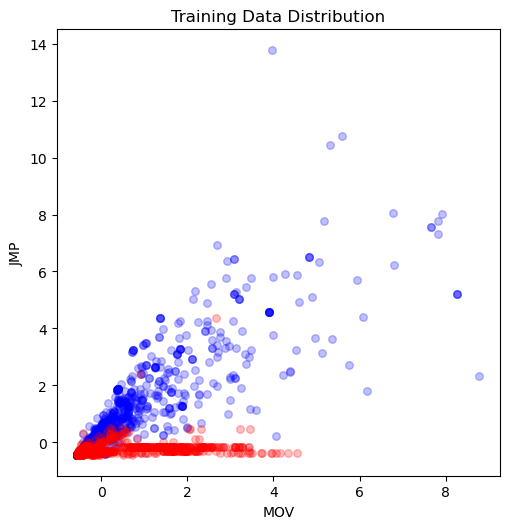

In [113]:
# --------------------------------------
# Add your P3 coding solution below.
# --------------------------------------

# print(df_malware.columns)
scalar = StandardScaler()
filtered_malware_df = df_malware[(df_malware['class'] == 1) | (df_malware['class'] == 2)]
filtered_malware_df['class'] = filtered_malware_df['class'].replace({1:1, 2:-1}).copy()

labels = filtered_malware_df.drop(columns=['class'])
processed_values_m =  scalar.fit_transform(labels)
processed_df_m = pd.DataFrame(processed_values_m, columns=labels.columns)
processed_df_m['class'] = filtered_malware_df['class'].values

# print(filtered_malware_df['jmp'].describe())
# print(processed_df_m['jmp'].describe())

ramnit = processed_df_m[processed_df_m['class']== 1]
lolipop = processed_df_m[processed_df_m['class']== -1]

plt.figure(figsize=(5, 5))
plt.scatter(ramnit['mov'], ramnit['jmp'], color='blue', s=30, alpha=0.25)
plt.scatter(lolipop['mov'], lolipop['jmp'], color='red', s=30, alpha=0.25)
plt.tight_layout()
plt.title("Training Data Distribution")
plt.xlabel("MOV")
plt.ylabel("JMP")
plt.show()

# print(processed_df_m.describe())






****

<img src="p4.png" width="600" style="float: right"/>


**P4** (10 Points): Support vector machine (SVM) classification model comparison.


Using the dataframe, this question will construct and evaluate **soft-margin L2 hinge-loss SVM classification models** to predict the label (**Ramnit** or **Lolipop**) based on the number of `MOV` and `JMP` instructions in the malware program. Specifically, 

**Dataset preparation**

Before model construction and evaluation, normalize the data (as done in **P3**), then shuffle and partition into two sets with a 90/10 split. Specifically, 90% of the data will be used to train, and 10% will be reserved for testing. You can write your own solution or use the Sklearn <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html">train_test_split</a> function (see authorized Python modules above).


**Accuracy**

You are required to implement a **handwritten L2 hinge-loss SVM classification model**, as specified in the slides. **Gradient descent** will be used to estimate the optimal parameters (that is, the full training set for each update).

First, train multiple models with varying `C`.
  - Use the following `C`: `[0.001,0.01,0.1,1]`.
  - Initialize all parameters to zeros.
  - Fix the number of training iterations to 1000 with a learning rate of `0.0001`.

Next, visualize the decision boundary for each model, and report the accuracy (ACC) for both the training and testing datasets in the plot title.

To receive full credit, your solution must generate plots similar to the reference. <span style="background-color: #FFFF00">**Note**: because the data is randomly shuffled each time the cell is run, your plot and measures will be slightly different than those provided</span>.

You may assume:
- Only the **testing data** is used to generate the scatter plots.
- The accuracy (ACC) measure for both the training and test datasets is reported in the plot title. These may be calculated using the <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html">accuracy_score</a> function (see authorized Python modules above). Round the accuracies to two 2 decimal places.
- The plot figure size is 12 inches in width and 10 inches in height.
- The plot figure uses a tight layout.
- The colors used to generate plots are blue (Ramnit), red (Lolipop), green (decision boundary), and dashed-green (+/-1 margins).
- The default x-axis and y-axis tick values are used.
- The scatter plot marker size is 30.
- The alpha (opacity) value is 0.25.
- The plot grid is enabled.
- <span style="background-color: #FFFF00">You must not use any existing SVM implementations or gradient descent procedures, such as `sklearn.svm.SVC` or `scipy.minimize`.</span>


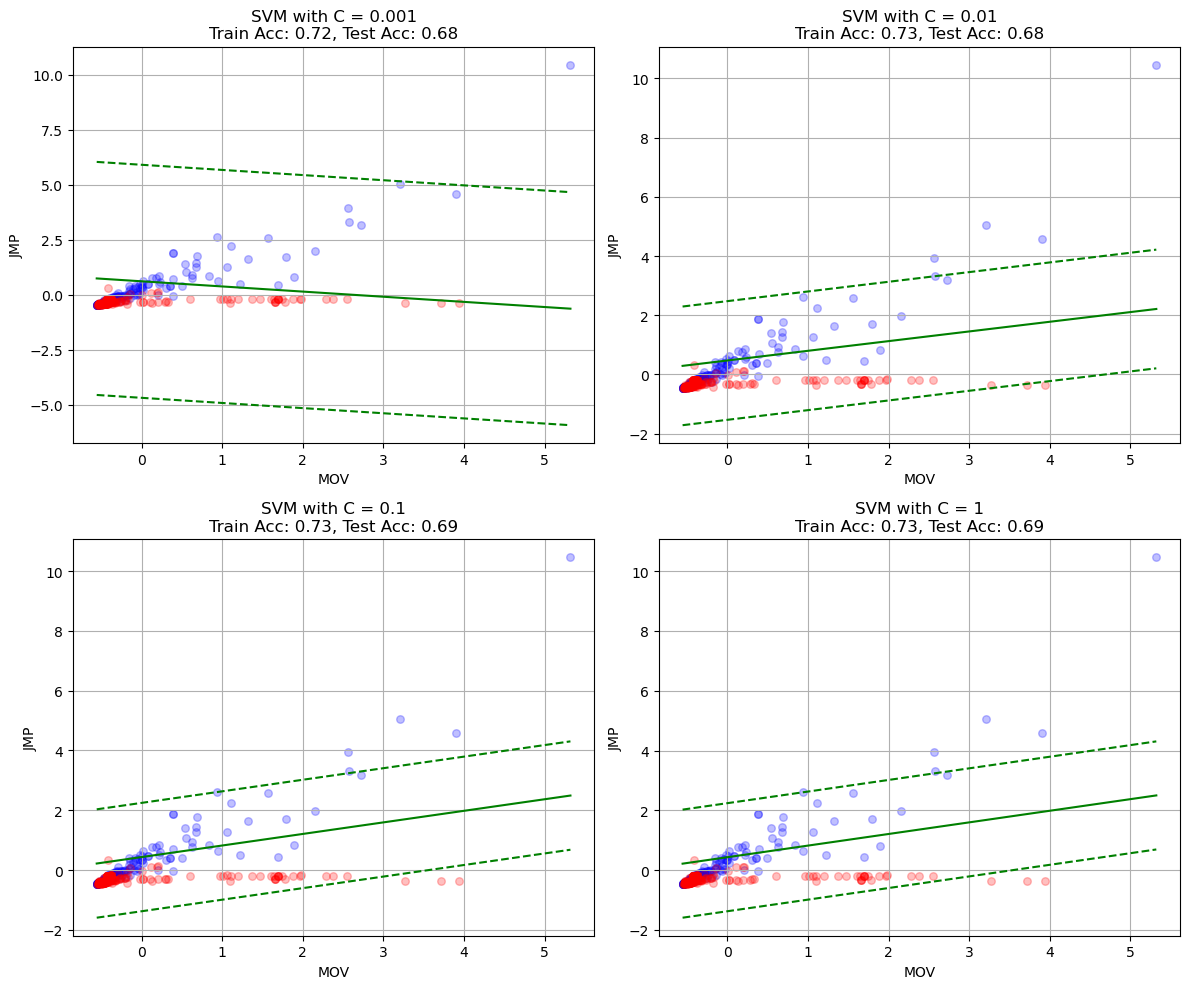

In [114]:
# --------------------------------------
# Add your P4 coding solution below.
# --------------------------------------

def svm_predict(X, params):
    return np.sign(X @ params)

def SVM_GD_trainer(X, y, C_values):
    N = 1000
    lr = 0.0001
    trained_params = {}
    for C in C_values:
        params = np.zeros((X.shape[1], 1))
        for i in range(N):
            margin = 1 - y * (X @ params)
            dw = params - 2 * C * (X.T @ (y * margin))
            params = params - lr * dw
        trained_params[C] = params
    return trained_params

C_values = [0.001, 0.01, 0.1, 1]

filtered_malware_df = df_malware[(df_malware['class'] == 1) | (df_malware['class'] == 2)].copy()
filtered_malware_df['class'] = filtered_malware_df['class'].replace({1: 1, 2: -1})
x_raw = filtered_malware_df[['mov', 'jmp']].to_numpy()

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_raw)
y_all = filtered_malware_df['class'].to_numpy().reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(x_scaled, y_all, test_size=0.1)

ones_train = np.ones((X_train.shape[0], 1))
ones_test = np.ones((X_test.shape[0], 1))
X_train_b = np.hstack([ones_train, X_train])
X_test_b = np.hstack([ones_test, X_test])

trained_params = SVM_GD_trainer(X_train_b, y_train, C_values)

# plot
plt.figure(figsize=(12, 10))

for idx, C in enumerate(C_values):
    params = trained_params[C]

    train_y_pred = svm_predict(X_train_b, params)
    test_y_pred = svm_predict(X_test_b, params)

    train_acc = round(acc(y_train, train_y_pred), 2)
    test_acc = round(acc(y_test, test_y_pred), 2)

    plt.subplot(2, 2, idx + 1)
    # scatter 
    ramnit_mask = y_test.flatten() == 1
    lolipop_mask = y_test.flatten() == -1
    plt.scatter(X_test[ramnit_mask, 0], X_test[ramnit_mask, 1],color='blue', s=30, alpha=0.25)
    plt.scatter(X_test[lolipop_mask, 0], X_test[lolipop_mask, 1],color='red', s=30, alpha=0.25)

    # decision boundary
    b, w1, w2 = params[0, 0], params[1, 0], params[2, 0]
    x1_vals = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 200)
    boundary = (-b - w1 * x1_vals)/w2
    margin_pos = (1 - b - w1 * x1_vals)/w2
    margin_neg = (-1 - b - w1 * x1_vals)/w2

    plt.plot(x1_vals, boundary, color='green', linestyle='-')
    plt.plot(x1_vals, margin_pos, color='green', linestyle='--')
    plt.plot(x1_vals, margin_neg, color='green', linestyle='--')

    plt.title(f'SVM with C = {C}\nTrain Acc: {train_acc}, Test Acc: {test_acc}')
    plt.xlabel('MOV')
    plt.ylabel('JMP')
    plt.grid(True)

plt.tight_layout()
plt.show()